<a href="https://colab.research.google.com/github/JiHyun13/deeplearning_and_lab_team.5/blob/main/%5B%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_5%EC%A1%B0%5D%EC%9D%B4%EC%88%98%EC%97%B0_%EA%B0%9C%EC%9D%B8%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 데이터 전처리

In [ ]:
import os
import re
import pandas as pd
import numpy as np
import pickle
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModel

In [ ]:
stop_words = {
    # 대명사
    "i", "me", "my", "myself", "we", "our", "you", "your",
    "he", "him", "his", "she", "her", "it", "its", "they", "them",
    # be동사 / 조동사
    "is", "am", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "do", "does", "did",
    "will", "would", "shall", "should", "can", "could",
    # 관사 / 전치사
    "a", "an", "the",
    "in", "on", "at", "to", "for", "of", "with", "by", "from",
    # 접속사 (but 제외)
    "and", "or", "if", "then",
    # 기타
    "this", "that", "these", "those",
    "there", "here", "what", "which", "who",
    "all", "each", "some", "any",
    "about", "up", "out",
}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ─── 데이터 로드 ───
data_path = r"/content/drive/MyDrive/학교/4학년/딥러닝실습/mosi_text_metadata.csv"
df = pd.read_csv(data_path)

print(f"데이터 수: {len(df)}")
print(f"\n샘플 확인:")
print(df[["text"]].head(5))

데이터 수: 2199

샘플 확인:
                                                text
0                          ANYHOW IT WAS REALLY GOOD
1  THAY DID THEY DIDNT REALLY DO A WHOLE BUNCH OF...
2                 I MEAN THEY DID A LITTLE BIT OF IT
3                              BUT NOT A WHOLE BUNCH
4                          AND THEY SHOULDVE I GUESS


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]','',text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df["tokens"] = df["text"].apply(preprocess_text)

print("전처리 전후 비교:")
for i in range(3):
    print(f"  원본:  {df['text'].iloc[i]}")
    print(f"  결과:  {df['tokens'].iloc[i]}")
    print()

전처리 전후 비교:
  원본:  ANYHOW IT WAS REALLY GOOD
  결과:  ['anyhow', 'really', 'good']

  원본:  THAY DID THEY DIDNT REALLY DO A WHOLE BUNCH OF BACKGROUND INFO ON WHY SHE HAS TO FIGHT AND BE PREPARED
  결과:  ['thay', 'didnt', 'really', 'whole', 'bunch', 'background', 'info', 'why', 'fight', 'prepared']

  원본:  I MEAN THEY DID A LITTLE BIT OF IT
  결과:  ['mean', 'little', 'bit']



In [ ]:
# 단어 사전 구축
all_tokens = []
for tokens in df["tokens"]:
    for token in tokens:
        all_tokens.append(token)

word_counts = Counter(all_tokens)
print(f"전체 고유 단어 수: {len(word_counts)}")
print(f"가장 많이 등장한 단어 10개: {word_counts.most_common(10)}")

#토큰 단어가 2번 이상 등장한 단어들만 놔두고 vocab 만들기
MIN_FREQ = 1
vocab = {"<PAD>": 0, "<UNK>": 1}
idx = 2

for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = idx #ex) vocab["like"] = 2 하면 vocab = {"<PAD>": 0, "<UNK>": 1, "like" : 2} 생성
        idx += 1

print(f"Vocab 크기: {len(vocab)}")

전체 고유 단어 수: 3039
가장 많이 등장한 단어 10개: [('like', 433), ('um', 421), ('movie', 407), ('really', 369), ('but', 354), ('just', 280), ('so', 204), ('know', 203), ('not', 169), ('good', 157)]
Vocab 크기: 3041


In [ ]:
#토큰 정수 인코딩
def encode_tokens(tokens, vocab):
    encoded = []
    for word in tokens:
        if word in vocab:
            encoded.append(vocab[word]) #vocab안에 있는 단어들만 정수 인코딩
        else:
            encoded.append(vocab["<UNK>"]) #없는것은 1(모름)으로
    return encoded

encoded_list = []
for t in df["tokens"]:
    encoded_list.append(encode_tokens(t,vocab))
df["encoded"] = encoded_list

print(f"인코딩 예시:")
print(f"  토큰: {df['tokens'].iloc[0]}")
print(f"  정수: {df['encoded'].iloc[0]}")


인코딩 예시:
  토큰: ['anyhow', 'really', 'good']
  정수: [2, 3, 4]


In [ ]:
# 인코딩 결과 저장
# save_dir = "deep"

save_data = {
    "encoded": df["encoded"].tolist(),
    "labels": df["label"].values,
    "video_ids": df["video_id"].values,
    "vocab": vocab,
    "texts": df["text"].values,
    "sentiment": df["sentiment"].values
}

save_path = "text_preprocessed.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"저장 완료: {save_path}")
print(f"  데이터 수: {len(save_data['encoded'])}")
print(f"  Vocab 크기: {len(vocab)}")

저장 완료: text_preprocessed.pkl
  데이터 수: 2199
  Vocab 크기: 3041


# 2. 패딩

In [ ]:
save_dir = "/content/drive/MyDrive/학교/4학년/딥러닝실습/text_preprocessed.pkl"

with open(save_dir,"rb") as last_file:
    text_data = pickle.load(last_file)

print("데이터 수:", len(text_data["encoded"]))
print("Vocab 크기:", len(text_data["vocab"]))
print("\n문장 길이 확인")
print("0번째 문장:", text_data["texts"][0])
print("0번째 문장 길이:", len(text_data["encoded"][0]))
print("0번째 문장 단어장 확인:", text_data["encoded"][0])
print("0번째 sentiment 확인: ", text_data["sentiment"][0])

vocab = text_data["vocab"]

데이터 수: 2199
Vocab 크기: 1370

문장 길이 확인
0번째 문장: ANYHOW IT WAS REALLY GOOD
0번째 문장 길이: 3
0번째 문장 단어장 확인: [1, 2, 3]
0번째 sentiment 확인:  2.4


* 타겟값을 sentiment로 설정

In [ ]:
MAX_LEN = 50
PAD_IDX = vocab["<PAD>"] #0

def pad_sequence(seq, max_len, pad_idx):
    if len(seq) >= max_len: #문장의 유의미한(토큰화된) 단어의 개수가 50개 이상이면
        return seq[:max_len] #자름
    return seq + [pad_idx] * (max_len - len(seq)) #0을 (50-기존 단어 개수)개로

X_padded = np.array([pad_sequence(seq, MAX_LEN, PAD_IDX) for seq in text_data["encoded"]]) #encoded = [4,2,3]같은 정수 인코딩
y = text_data["sentiment"].astype(np.float32) # 실수형 감정 점수 sentiment를 타겟으로 설정
print(f"X_padded shape: {X_padded.shape}")

X_padded shape: (2199, 50)


# 3. 학습, 테스트 나누기

In [ ]:
# 데이터 DataLoader 변환
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,y,test_size=0.2,random_state=42
)

print(f"Train_data: {len(X_train)} | Test_data: {len(X_test)}")

Train_data: 1759 | Test_data: 440


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device} | vocab: {len(vocab)} | train: {len(X_train)} | test: {len(X_test)}")

device: cpu | vocab: 1370 | train: 1759 | test: 440


# 4. 모델 함수 + 훈련, 평가 정의

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(input_size=embed_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim,1)# 회귀이기 때문에 출력값 하나만

    def forward(self, x):
        emb = self.embedding(x)
        output, h_n = self.gru(emb)
        h_pool = torch.mean(output, dim=1) # 평균 풀링으로 문맥 압축
        return self.fc(h_pool)


class LSTMModel(nn.Module):
    # 출력 노드 1개 (회귀)
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1) # 회귀이기 때문에 출력값 하나만

    def forward(self, x):
        emb = self.embedding(x)
        output, (h_n,c_n) = self.lstm(emb)
        h_pool = torch.mean(output, dim=1)
        return self.fc(h_pool)

#오차 평가
def eval_mae(model, loader):
    model.eval()
    total_error = 0.0 # 총 틀린 점수
    total_count = 0 # 총 푼 문제 개수
    with torch.no_grad(): #기울기 계산 끄기
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).squeeze() #타켓값 차원에 맞추기 위해 모델 출력값 1차원으로 변경
            error = torch.abs(pred - yb) # 예측값 - 실제값 절댓값
            total_error += error.sum().item()
            total_count += yb.numel()
    return total_error / total_count


#훈련 및 평가 함수
def train_and_evaluate(model, optimizer, criterion, train_loader, test_loader, device, epochs=20, verbose=True):
    history = {"loss": [], "train_mae": [], "test_mae": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()#기울기 0으로 초기화
            pred = model(xb).squeeze()#모델 학습후 1차원으로 맞추기
            loss = criterion(pred, yb)#오차함수
            loss.backward()#역전파
            optimizer.step()#업데이트
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_mae = eval_mae(model,train_loader)
        current_mae = eval_mae(model, test_loader)

        history["loss"].append(epoch_loss)
        history["train_mae"].append(train_mae)
        history["test_mae"].append(current_mae)
        if verbose:
          print(f"   Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Train MAE: {train_mae:.4f}| Test MAE: {current_mae:.4f}")

    return model, history

# Basic model

In [ ]:
final_trained_models = {}
history = {}
criterion = nn.MSELoss()# 회귀용 오차 함수


In [ ]:
models = {
    "Basic_LSTM": LSTMModel(vocab_size=len(vocab)),
    "Basic_GRU":  GRUModel(vocab_size=len(vocab)),
}

for tag, model in models.items():
    print(f'{tag}: ')
    model = model.to(device)
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
    trained_model, hist = train_and_evaluate(model, optimizer, criterion, train_loader, test_loader, device, epochs=20) #훈련

    final_trained_models[tag] = trained_model
    history[tag] = hist

Basic_LSTM: 
   Epoch 01 | Loss: 2.4751 | Train MAE: 1.3613| Test MAE: 1.3552
   Epoch 02 | Loss: 2.2918 | Train MAE: 1.2270| Test MAE: 1.2634
   Epoch 03 | Loss: 1.9483 | Train MAE: 1.0673| Test MAE: 1.1522
   Epoch 04 | Loss: 1.6777 | Train MAE: 0.9829| Test MAE: 1.1180
   Epoch 05 | Loss: 1.4698 | Train MAE: 0.8869| Test MAE: 1.0983
   Epoch 06 | Loss: 1.2932 | Train MAE: 0.8534| Test MAE: 1.0873
   Epoch 07 | Loss: 1.1529 | Train MAE: 0.7929| Test MAE: 1.0801
   Epoch 08 | Loss: 1.0305 | Train MAE: 0.7301| Test MAE: 1.1064
   Epoch 09 | Loss: 0.9747 | Train MAE: 0.7395| Test MAE: 1.0765
   Epoch 10 | Loss: 0.8901 | Train MAE: 0.6596| Test MAE: 1.1008
   Epoch 11 | Loss: 0.7502 | Train MAE: 0.6248| Test MAE: 1.0330
   Epoch 12 | Loss: 0.6434 | Train MAE: 0.5882| Test MAE: 1.0617
   Epoch 13 | Loss: 0.5733 | Train MAE: 0.5313| Test MAE: 1.0432
   Epoch 14 | Loss: 0.5244 | Train MAE: 0.5178| Test MAE: 1.0484
   Epoch 15 | Loss: 0.5061 | Train MAE: 0.4938| Test MAE: 1.0027
   Epoch 16 

# 차별점: Optuna 하이퍼파라미터 최적화 자동화

In [ ]:
!pip install optuna

In [ ]:
import optuna

def objective_gru(trial):
   # 하이퍼파라미터 범위 지정
    embed_dim = trial.suggest_categorical('embed_dim', [32, 64, 128, 256])
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128, 256])
    num_layers = trial.suggest_int('num_layers', 1, 2)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    #GRU모델로 학습 결정 정의
    model = GRUModel(vocab_size=len(vocab), embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    #학습 및 평가
    train_and_evaluate(model, optimizer, criterion, train_loader, test_loader, device, epochs=5, verbose=False)

    return eval_mae(model, test_loader)



def objective_lstm(trial):
  # 하이퍼파라미터 범위 지정
    embed_dim = trial.suggest_categorical('embed_dim', [32, 64, 128, 256])
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128, 256])
    num_layers = trial.suggest_int('num_layers', 1, 2)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    # LSTMModel로 학습 결정 정의
    model = LSTMModel(vocab_size=len(vocab), embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    #학습 및 평가
    train_and_evaluate(model, optimizer, criterion, train_loader, test_loader, device, epochs=5, verbose=False)

    return eval_mae(model, test_loader)

## GRU+Optuna

In [ ]:
# GRU 최적화 실행
study_gru = optuna.create_study(direction='minimize')
study_gru.optimize(objective_gru, n_trials=30)

[I 2026-04-18 08:04:11,730] A new study created in memory with name: no-name-29689337-e34e-4043-a00d-8395669ff14d
[I 2026-04-18 08:04:37,097] Trial 0 finished with value: 1.0878008408979936 and parameters: {'embed_dim': 128, 'hidden_dim': 32, 'num_layers': 2, 'lr': 0.0015890643575957283}. Best is trial 0 with value: 1.0878008408979936.
[I 2026-04-18 08:05:14,611] Trial 1 finished with value: 0.9777975775978782 and parameters: {'embed_dim': 256, 'hidden_dim': 128, 'num_layers': 1, 'lr': 0.0017394156197650364}. Best is trial 1 with value: 0.9777975775978782.
[I 2026-04-18 08:05:29,169] Trial 2 finished with value: 1.1021683172746137 and parameters: {'embed_dim': 128, 'hidden_dim': 128, 'num_layers': 1, 'lr': 0.0005687374908896755}. Best is trial 1 with value: 0.9777975775978782.
[I 2026-04-18 08:05:38,096] Trial 3 finished with value: 1.0316523465243252 and parameters: {'embed_dim': 128, 'hidden_dim': 32, 'num_layers': 2, 'lr': 0.0020217105840764174}. Best is trial 1 with value: 0.977797

In [ ]:
#GRU 최적의 하이퍼파라미터
print(f"GRU 최적의 하이퍼파라미터: {study_gru.best_params}")
print(f"MAE: {study_gru.best_value:.4f}")

best_params_gru = study_gru.best_params

#최적의 파라미터로 다시 GRU를 학습함
final_model_gru = GRUModel(
    vocab_size=len(vocab),
    embed_dim=best_params_gru['embed_dim'],
    hidden_dim=best_params_gru['hidden_dim'],
    num_layers=best_params_gru['num_layers']
).to(device)

# 최적의 학습률(lr)도 가져와서 최적화에 넣음
best_lr_gru = study_gru.best_params['lr']
optimizer_final_gru = optim.Adam(final_model_gru.parameters(), lr=best_lr_gru)


# 최종 모델 학습
trained_optuna_gru, hist_gru = train_and_evaluate(
    final_model_gru,optimizer_final_gru, criterion, train_loader, test_loader, device, epochs=20, verbose=True
)

final_trained_models["Optuna_GRU"] = trained_optuna_gru
history["Optuna_GRU"] = hist_gru

GRU 최적의 하이퍼파라미터: {'embed_dim': 256, 'hidden_dim': 128, 'num_layers': 1, 'lr': 0.0044346197004340214}
MAE: 0.8848
   Epoch 01 | Loss: 2.2398 | Train MAE: 1.0797| Test MAE: 1.1765
   Epoch 02 | Loss: 1.4340 | Train MAE: 0.7926| Test MAE: 1.0918
   Epoch 03 | Loss: 0.9058 | Train MAE: 0.5875| Test MAE: 0.9972
   Epoch 04 | Loss: 0.5653 | Train MAE: 0.5337| Test MAE: 0.9705
   Epoch 05 | Loss: 0.3794 | Train MAE: 0.3751| Test MAE: 0.9840
   Epoch 06 | Loss: 0.2456 | Train MAE: 0.2863| Test MAE: 0.9586
   Epoch 07 | Loss: 0.1631 | Train MAE: 0.2347| Test MAE: 0.9569
   Epoch 08 | Loss: 0.1127 | Train MAE: 0.1871| Test MAE: 0.9403
   Epoch 09 | Loss: 0.0768 | Train MAE: 0.1596| Test MAE: 0.9376
   Epoch 10 | Loss: 0.0622 | Train MAE: 0.1365| Test MAE: 0.9517
   Epoch 11 | Loss: 0.0491 | Train MAE: 0.1252| Test MAE: 0.9516
   Epoch 12 | Loss: 0.0414 | Train MAE: 0.1317| Test MAE: 0.9562
   Epoch 13 | Loss: 0.0409 | Train MAE: 0.1371| Test MAE: 0.9597
   Epoch 14 | Loss: 0.0376 | Train MAE: 0.

## LSTM + Optuna

In [ ]:
# LSTM 최적화 실행
study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(objective_lstm, n_trials=30)

[I 2026-04-18 08:17:35,614] A new study created in memory with name: no-name-8ba43ef8-e5f4-46d5-819a-cc2e2decac0f
[I 2026-04-18 08:17:43,466] Trial 0 finished with value: 1.0990929170088335 and parameters: {'embed_dim': 128, 'hidden_dim': 64, 'num_layers': 1, 'lr': 0.00154799628604644}. Best is trial 0 with value: 1.0990929170088335.
[I 2026-04-18 08:18:36,566] Trial 1 finished with value: 1.069195860082453 and parameters: {'embed_dim': 256, 'hidden_dim': 256, 'num_layers': 1, 'lr': 0.00026208592540629246}. Best is trial 1 with value: 1.069195860082453.
[I 2026-04-18 08:19:23,874] Trial 2 finished with value: 1.0223901575261896 and parameters: {'embed_dim': 256, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.0017731779678495097}. Best is trial 2 with value: 1.0223901575261896.
[I 2026-04-18 08:19:41,917] Trial 3 finished with value: 1.096234113519842 and parameters: {'embed_dim': 128, 'hidden_dim': 128, 'num_layers': 1, 'lr': 0.004319754279388881}. Best is trial 2 with value: 1.0223901575

In [ ]:
# LSTM 최적의 하이퍼파라미터
print(f"LSTM 최적의 하이퍼파라미터: {study_lstm.best_params}")
print(f"MAE: {study_lstm.best_value:.4f}")

best_params_lstm = study_lstm.best_params

#최적의 파라미터로 다시 LSTM를 학습함
final_mode_lstm = LSTMModel(
    vocab_size=len(vocab),
    embed_dim=best_params_lstm['embed_dim'],
    hidden_dim=best_params_lstm['hidden_dim'],
    num_layers=best_params_lstm['num_layers']
).to(device)

# 최적의 학습률(lr)도 가져와서 최적화에 넣음
best_lr_lstm = study_lstm.best_params['lr']
optimizer_final_lstm = optim.Adam(final_mode_lstm.parameters(), lr=best_lr_lstm)


#학습
trained_optuna_lstm, hist_lstm = train_and_evaluate(
    final_mode_lstm, optimizer_final_lstm, criterion, train_loader, test_loader, device, epochs=20, verbose=True
)


final_trained_models["Optuna_LSTM"] = trained_optuna_lstm
history["Optuna_LSTM"] = hist_lstm

LSTM 최적의 하이퍼파라미터: {'embed_dim': 256, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.0036938229811333797}
MAE: 0.9301
   Epoch 01 | Loss: 2.2379 | Train MAE: 1.0895| Test MAE: 1.2111
   Epoch 02 | Loss: 1.4814 | Train MAE: 0.9517| Test MAE: 1.1970
   Epoch 03 | Loss: 1.3103 | Train MAE: 0.9132| Test MAE: 1.1892
   Epoch 04 | Loss: 1.2481 | Train MAE: 0.7833| Test MAE: 1.1183
   Epoch 05 | Loss: 1.0847 | Train MAE: 0.7583| Test MAE: 1.1071
   Epoch 06 | Loss: 0.9932 | Train MAE: 0.7613| Test MAE: 1.0593
   Epoch 07 | Loss: 0.8750 | Train MAE: 0.6573| Test MAE: 1.0513
   Epoch 08 | Loss: 0.7320 | Train MAE: 0.5877| Test MAE: 1.0050
   Epoch 09 | Loss: 0.5799 | Train MAE: 0.4994| Test MAE: 1.0058
   Epoch 10 | Loss: 0.4491 | Train MAE: 0.4368| Test MAE: 1.0034
   Epoch 11 | Loss: 0.3893 | Train MAE: 0.4008| Test MAE: 0.9737
   Epoch 12 | Loss: 0.2929 | Train MAE: 0.3693| Test MAE: 0.9722
   Epoch 13 | Loss: 0.2397 | Train MAE: 0.3210| Test MAE: 0.9730
   Epoch 14 | Loss: 0.1910 | Train MAE: 0

# 시각화

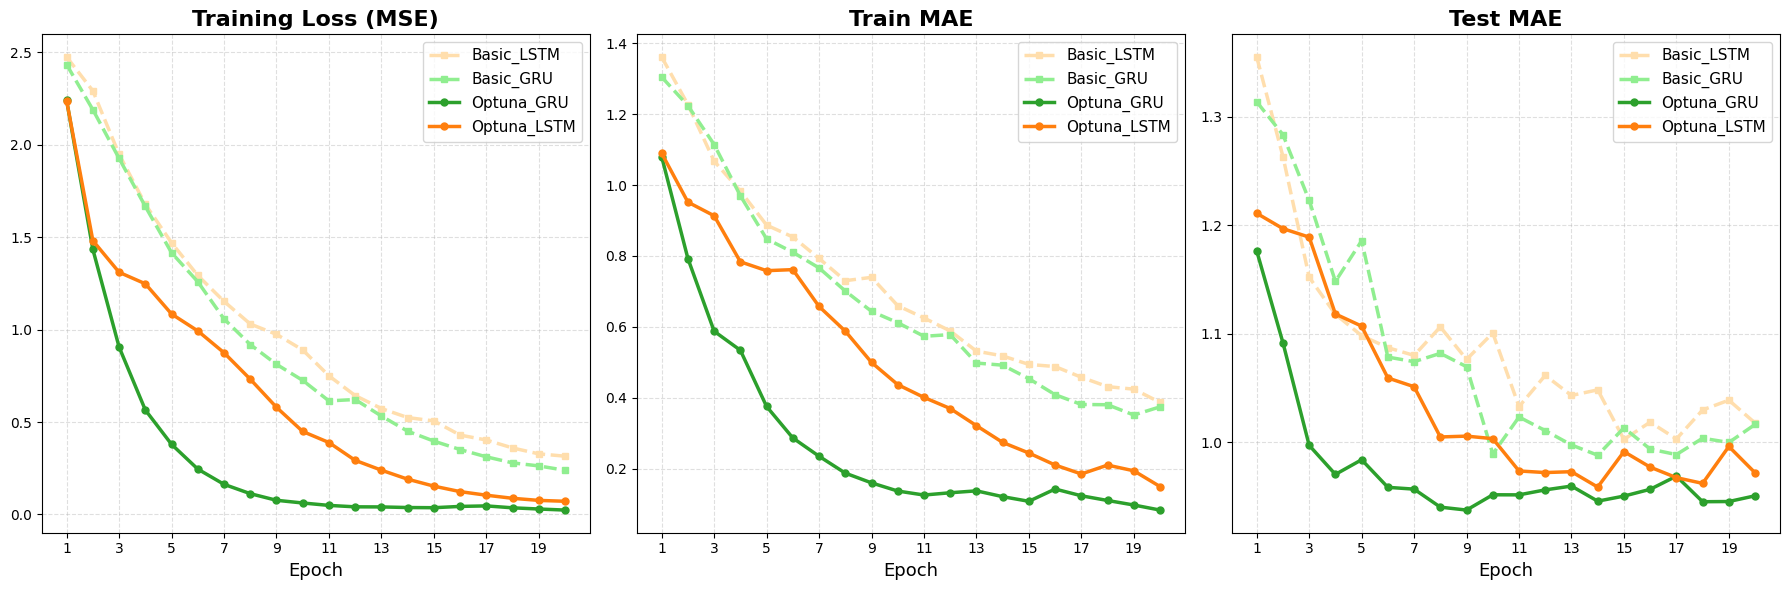


[최종 모델 성능 순위] (MAE)
 1위: Optuna_GRU | train: 0.0828 |test: 0.9508 점
 2위: Optuna_LSTM | train: 0.1491 |test: 0.9720 점
 3위: Basic_GRU | train: 0.3741 |test: 1.0165 점
 4위: Basic_LSTM | train: 0.3866 |test: 1.0178 점


In [ ]:
import matplotlib.pyplot as plt

# Basic은 점선, Optuna는 실선, GRU는 초록, LSTM는 주황색으로 구분
model_styles = {
    "Optuna_GRU":  {"color": "tab:green",  "ls": "-",  "marker": "o"},
    "Optuna_LSTM": {"color": "tab:orange", "ls": "-",  "marker": "o"},
    "Basic_GRU":   {"color": "lightgreen", "ls": "--", "marker": "s"},
    "Basic_LSTM":  {"color": "navajowhite", "ls": "--", "marker": "s"}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for tag_name, res in history.items():
    style = model_styles.get(tag_name, {"color": "gray", "ls": "-", "marker": "x"})
    ep = range(1, len(res["loss"]) + 1)

    axes[0].plot(ep, res["loss"], color=style["color"], linestyle=style["ls"],
                 marker=style["marker"], ms=5, label=tag_name, linewidth=2.5)

    axes[1].plot(ep, res["train_mae"], color=style["color"], linestyle=style["ls"],marker=style["marker"], ms=5, label=tag_name, linewidth=2.5)

    axes[2].plot(ep, res["test_mae"], color=style["color"], linestyle=style["ls"],
                 marker=style["marker"], ms=5, label=tag_name, linewidth=2.5)

# 그래프 꾸미기
titles = ["Training Loss (MSE)", "Train MAE", "Test MAE"]
for ax, t in zip(axes, titles):
    ax.set_title(t, fontweight="bold", fontsize=16)
    ax.set_xlabel("Epoch", fontsize=13)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.4, linestyle='--')
    max_ep = len(next(iter(history.values()))["loss"])
    ax.set_xticks(range(1, max_ep + 1, 2 if max_ep > 10 else 1))

plt.tight_layout()
plt.show()

# 최종 성적
print("\n[최종 모델 성능 순위] (MAE)")

sorted_results = sorted(history.items(), key=lambda x: x[1]["test_mae"][-1])

for i, (tag_name, res) in enumerate(sorted_results):
    final_mae = res["test_mae"][-1]if "train_mae" in res else 0.0
    final_train_mae = res["train_mae"][-1] if "train_mae" in res else 0.0
    if i == 0:
      medal = "1위:"
    elif i == 1:
      medal = "2위:"
    elif i == 2:
      medal = "3위:"
    else:
      medal = "4위:"

    print(f" {medal} {tag_name} | train: {final_train_mae:.4f} |test: {final_mae:.4f} 점")

In [ ]:
import torch

def predict_emotion(text, model, vocab, max_len=50, pad_idx=0):
    model.eval()

    # 토큰화
    tokens = preprocess_text(text)

    # 인수 인코딩
    seq = encode_tokens(tokens, vocab)

    # 패딩
    padded_seq = pad_sequence(seq, max_len, pad_idx)

    # 텐서로 변환
    tensor = torch.LongTensor(padded_seq).unsqueeze(0).to(device)

    # 예측
    with torch.no_grad():
        prediction = model(tensor).squeeze().item()

    return prediction

# 기여도 분석
def analyze_word_contribution(sentence, model, vocab):
    model.eval()
    words = sentence.split()

    base_score = predict_emotion(sentence, model, vocab)
    if base_score>0:
      result = "긍정"
    else:
      result ="부정"

    print(f"전체 문장 감정 예측: {base_score:.2f}점 ({result})")
    print(f"{'단어':<15} | {'기여도':<15}")
    print("-" * 35)

    for word in words:
        # 해당 단어만 빼고 문장 재조합
        sub_sentence = " ".join([w for w in words if w != word])

        sub_score = predict_emotion(sub_sentence, model, vocab)

        # 기여도 = 전체 점수 - 단어 뺐을 때 점수
        contribution = base_score - sub_score

        # 결과 출력
        if contribution > 0:
            trend = "긍정"
        else:
            trend = "부정"

        print(f"{word:<15} | {contribution:>8.4f}  ({trend})")
    print("-" * 35)
    print()


#테스트
test_text = {"I am so happy and excited",#긍정 문장
             "Terrible acting and bad story.", #부정 문장
             "I was so happy in the morning, but now I am depressed"} #섞인 문장

best_model_name = "Optuna_GRU"
best_model = final_trained_models[best_model_name]

# 기여도 분석
for i in test_text:
  print(f'문장: {i}')
  analyze_word_contribution(i, best_model, vocab)

문장: Terrible acting and bad story.
전체 문장 감정 예측: -1.85점 (부정)
단어              | 기여도            
-----------------------------------
Terrible        |   0.0705  (긍정)
acting          |   0.0955  (긍정)
and             |   0.0000  (부정)
bad             |  -0.2709  (부정)
story.          |   0.3930  (긍정)
-----------------------------------

문장: I am so happy and excited
전체 문장 감정 예측: 2.21점 (긍정)
단어              | 기여도            
-----------------------------------
I               |   0.0000  (부정)
am              |   0.0000  (부정)
so              |   0.5058  (긍정)
happy           |   0.2122  (긍정)
and             |   0.0000  (부정)
excited         |   0.2507  (긍정)
-----------------------------------

문장: I was so happy in the morning, but now I am depressed
전체 문장 감정 예측: -1.15점 (부정)
단어              | 기여도            
-----------------------------------
I               |   0.0000  (부정)
was             |   0.0000  (부정)
so              |   0.0947  (긍정)
happy           |   0.1716  (긍정)
in              |   0.00